<a href="https://colab.research.google.com/github/MARIAHUSSAIN123/Random-forest-decision-tree/blob/main/randomforest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**multiple decision trees**

**📌 STEP 1 — Import libraries **

In [ ]:
# Numerical operations
import numpy as np

# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train test split
from sklearn.model_selection import train_test_split

# Encoding categorical data
from sklearn.preprocessing import LabelEncoder

# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

**📌 STEP 2 — Load Dataset**

In [5]:
df = pd.read_csv('/content/Heart_Disease_Prediction.csv')

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


**📌 STEP 3 — Understand Dataset**

In [6]:
print("Shape:", df.shape)

print("\nColumns:\n")
df.columns

print("\nDataset Info:\n")
df.info()

Shape: (270, 14)

Columns:


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-nul

**📌 STEP 4 — Check Missing Values**

In [7]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


**📌 STEP 5 — Encode Categorical Data**

In [8]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['Heart Disease'], dtype='object')

In [9]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

**📌 STEP 6 — Check Dataset**

In [10]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


**📌 STEP 7 — Feature & Target Split**

In [11]:
X = df.drop('Heart Disease', axis=1)

y = df['Heart Disease']

**📌 STEP 8 — Train Test Split**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**📌 STEP 9 — Create Random Forest Model**

In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

**📌 STEP 10 — Train Model**

In [14]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**📌 STEP 11 — Prediction**

In [15]:
y_pred = model.predict(X_test)

**📌 STEP 12 — Accuracy**

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7962962962962963


**📌 STEP 13 — Confusion Matrix**

In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[29  4]
 [ 7 14]]


**📌 STEP 14 — Classification Report**

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        33
           1       0.78      0.67      0.72        21

    accuracy                           0.80        54
   macro avg       0.79      0.77      0.78        54
weighted avg       0.79      0.80      0.79        54



**📌 STEP 15 — Confusion Matrix Visualization**

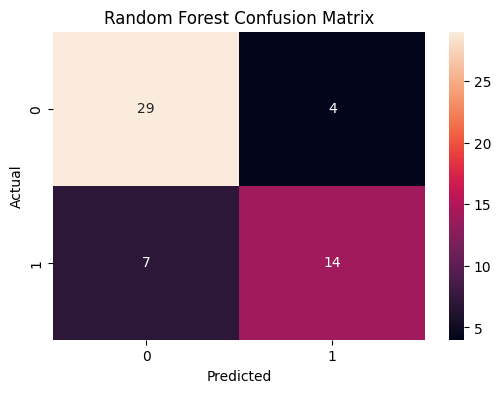

In [19]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

**📌 STEP 16 — Feature Importance**

In [20]:
importance = model.feature_importances_

features = X.columns

In [21]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
9,ST depression,0.138002
2,Chest pain type,0.133470
12,Thallium,0.114730
7,Max HR,0.105259
0,Age,0.095171
11,Number of vessels fluro,0.085092
4,Cholesterol,0.083485
3,BP,0.079547
10,Slope of ST,0.059689
8,Exercise angina,0.052720


**📌 STEP 17 — Feature Importance Graph**

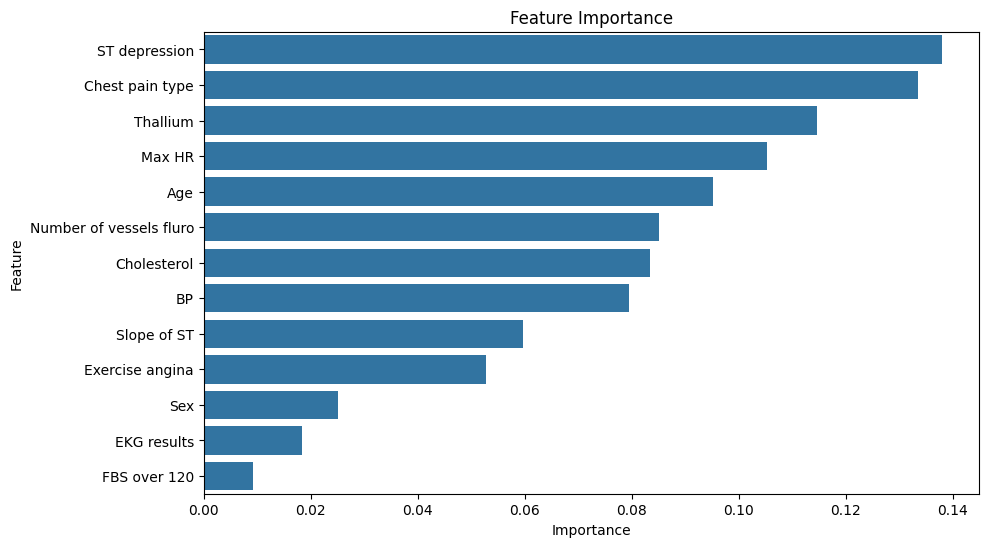

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

**📌 STEP 18 — Conclusion**

# Conclusion

Random Forest Classifier was successfully
implemented for heart disease prediction.

The model achieved strong classification accuracy
and performed better than a single Decision Tree.

Feature importance analysis helped identify
the most influential medical features.